In [11]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict,Literal

In [12]:
class QuadState(TypedDict):
    
    a:int
    b:int
    c:int
    
    equation:str
    discriminant:float
    result:str

In [13]:

def show_equation(state:QuadState):
     b = f"+{state['b']}" if state["b"] >= 0 else str(state["b"])
     c = f"+{state['c']}" if state["c"] >= 0 else str(state["c"])
     
     equation=f"{state['a']}X^2{b}X{c}"
     
     return {"equation":equation}

def calc_discrimnant(state:QuadState):
    discriminant=(state["b"]**2)-(4*state["a"]*state["c"])
    return {'discriminant':discriminant}
 
def real_roots(state: QuadState):

    root1 = (-state["b"] + state["discriminant"]**0.5)/(2*state["a"])
    root2 = (-state["b"] - state["discriminant"]**0.5)/(2*state["a"])

    result = f'The roots are {root1} and {root2}'

    return {'result': result}
 
def repeated_roots(state: QuadState):
    root = (-state["b"])/(2*state["a"])
    result = f'Only repeating root is {root}'
    return {'result': result}

def no_real_roots(state: QuadState):
    result = f'No real roots'
    return {'result': result}

def check_condition(state: QuadState) -> Literal["real_roots", "repeated_roots", "no_real_roots"]:
    if state['discriminant'] > 0:
        return "real_roots"
    elif state['discriminant'] == 0:
        return "repeated_roots"
    else:
        return "no_real_roots"
    

In [14]:
# Graph 
graph=StateGraph(QuadState)

# Add Nodes
graph.add_node("show_equation",show_equation)
graph.add_node("calc_discrimnant",calc_discrimnant)
graph.add_node("real_roots",real_roots)
graph.add_node("repeated_roots",repeated_roots)
graph.add_node("no_real_roots",no_real_roots)


# Add Edges
graph.add_edge(START,"show_equation")
graph.add_edge("show_equation","calc_discrimnant")

graph.add_conditional_edges("calc_discrimnant",check_condition)
graph.add_edge("real_roots",END)
graph.add_edge("repeated_roots",END)
graph.add_edge("no_real_roots",END)

# Compile The Graph
workflow=graph.compile()


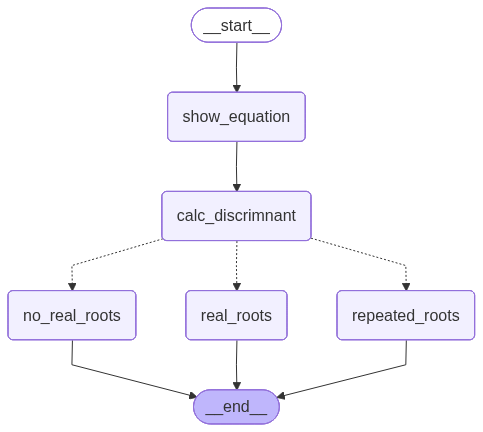

In [9]:
workflow

In [15]:
initial_state = {
    'a': 2, 
    'b': 4,
    'c': 2
}

workflow.invoke(initial_state)

{'a': 2,
 'b': 4,
 'c': 2,
 'equation': '2X^2+4X+2',
 'discriminant': 0,
 'result': 'Only repeating root is -1.0'}